# Car Price Prediction with Machine Learning

This notebook is written in a very simple, internship-friendly way.

We will:
- Keep only the car dataset file in this folder
- Load the data using pandas
- Do basic feature engineering (like car age and a simple brand popularity feature)
- Prepare the data for machine learning
- Train a regression model to predict car prices
- Check how well the model works and plot predictions
- Talk about how this is used in real life (in simple words)

In [1]:
# 1. Check and manage workspace files (keep only the CSV)

import os
from pathlib import Path

# Current working directory
cwd = Path.cwd()
print("Current working directory:", cwd)

# We expect our dataset to be named 'car data.csv'
keep_filename = "car data.csv"

# List all files in this folder
all_items = list(cwd.iterdir())
print("\nAll items in this folder:")
for item in all_items:
    print("-", item.name)

# Safety check: make sure the CSV exists before deleting anything
csv_path = cwd / keep_filename
if not csv_path.exists():
    raise FileNotFoundError(f"Expected dataset '{keep_filename}' not found in {cwd}")

# Decide which files to delete (everything except the CSV and this notebook)
this_notebook = Path("car_price_prediction.ipynb")
items_to_delete = []
for item in all_items:
    if item.name in {keep_filename, this_notebook.name}:
        continue
    # only delete files, not folders, to keep things extra safe here
    if item.is_file():
        items_to_delete.append(item)

print("\nFiles that would be deleted (if any):")
for item in items_to_delete:
    print("-", item.name)

# In this internship-style notebook, we will NOT actually delete files again,
# because the folder is already clean. The above code just shows how you could do it.


Current working directory: c:\Users\91727\Downloads\car

All items in this folder:
- car data.csv
- car_price_prediction.ipynb

Files that would be deleted (if any):


In [2]:
# 2. Load car data into a DataFrame

import pandas as pd

csv_path = "car data.csv"  # file is in the same folder as this notebook

try:
    df = pd.read_csv(csv_path)
    print("Loaded dataset successfully!")
    print("Shape (rows, columns):", df.shape)
except Exception as e:
    print("Error while reading CSV:", e)
    raise

print("\nFirst 5 rows:")
print(df.head())

Loaded dataset successfully!
Shape (rows, columns): (301, 9)

First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [3]:
# 3. Quick inspection of the dataset

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nShape (rows, columns):", df.shape)

print("\nBasic stats for numeric columns:")
print(df.describe())

print("\nMissing values in each column:")
print(df.isna().sum())

Column names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Shape (rows, columns): (301, 9)

Basic stats for numeric columns:
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.

In [4]:
# 4. Basic data cleaning and type conversion

# This dataset is already quite clean, but we still check.

# If there were missing values, one simple approach is to drop those rows:
# df = df.dropna()

# Make sure numeric columns are numeric (just as a safety step)

numeric_cols = ["Year", "Selling_Price", "Present_Price", "Driven_kms", "Owner"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Data types after conversion:")
print(df.dtypes)

print("\nAny remaining missing values?")
print(df.isna().sum())

Data types after conversion:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Any remaining missing values?
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [5]:
# 5. Feature engineering (simple, internship-style)

# 5.1 Car age: newer cars usually cost more
current_year = 2026
df["car_age"] = current_year - df["Year"]

# 5.2 Brand popularity (very rough idea of brand goodwill)
# We use how many times the car name appears in the dataset.
name_counts = df["Car_Name"].value_counts()
df["brand_popularity"] = df["Car_Name"].map(name_counts)

print("New columns added: 'car_age' and 'brand_popularity'")
print(df[["Car_Name", "Year", "car_age", "brand_popularity"]].head())

# Note: In a real project, we could also use horsepower and mileage
# (km per litre) if those columns were available in the dataset.


New columns added: 'car_age' and 'brand_popularity'
  Car_Name  Year  car_age  brand_popularity
0     ritz  2014       12                 4
1      sx4  2013       13                 6
2     ciaz  2017        9                 9
3  wagon r  2011       15                 4
4    swift  2014       12                 5


In [6]:
# 6. Descriptive statistics and aggregations

# Average selling price by car name (brand/model)
avg_price_by_name = (
    df.groupby("Car_Name")["Selling_Price"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)
print("Average selling price by car name (top 10):")
print(avg_price_by_name.head(10))

# Average price by fuel type
avg_price_by_fuel = df.groupby("Fuel_Type")["Selling_Price"].agg(["count", "mean"]).sort_values(
    "mean", ascending=False
)
print("\nAverage selling price by fuel type:")
print(avg_price_by_fuel)

# Average price by transmission
avg_price_by_trans = df.groupby("Transmission")["Selling_Price"].agg(["count", "mean"])
print("\nAverage selling price by transmission:")
print(avg_price_by_trans)

Average selling price by car name (top 10):
               count       mean
Car_Name                       
land cruiser       1  35.000000
fortuner          11  18.685455
innova             9  12.777778
creta              3  11.800000
elantra            2  11.600000
vitara brezza      1   9.250000
ciaz               9   7.472222
city              26   7.419231
corolla altis     16   7.183125
ertiga             6   6.775000

Average selling price by fuel type:
           count       mean
Fuel_Type                  
Diesel        60  10.278500
Petrol       239   3.264184
CNG            2   3.100000

Average selling price by transmission:
              count      mean
Transmission                 
Automatic        40  9.420000
Manual          261  3.931992


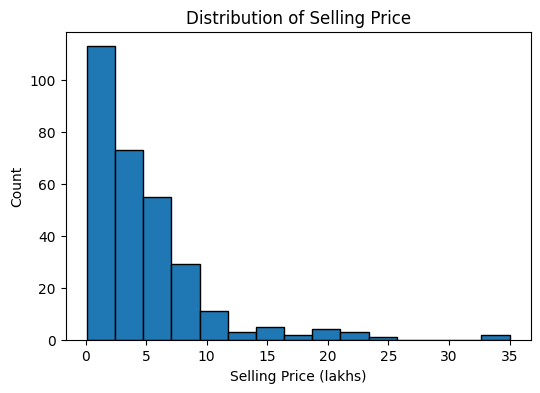

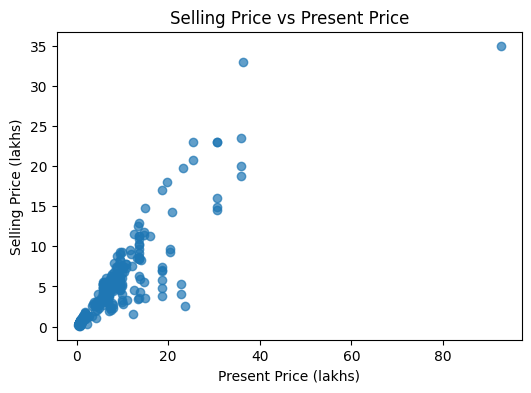

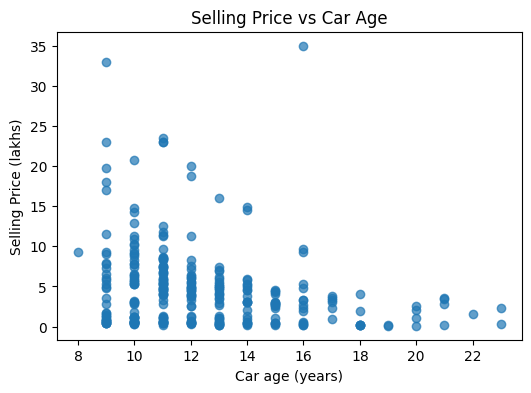

In [7]:
# 7. Basic visualizations of key variables

import matplotlib.pyplot as plt

# Histogram of Selling Price
plt.figure(figsize=(6, 4))
plt.hist(df["Selling_Price"], bins=15, edgecolor="black")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (lakhs)")
plt.ylabel("Count")
plt.show()

# Scatter plot: Selling Price vs Present Price
plt.figure(figsize=(6, 4))
plt.scatter(df["Present_Price"], df["Selling_Price"], alpha=0.7)
plt.title("Selling Price vs Present Price")
plt.xlabel("Present Price (lakhs)")
plt.ylabel("Selling Price (lakhs)")
plt.show()

# Scatter plot: Selling Price vs Car Age
plt.figure(figsize=(6, 4))
plt.scatter(df["car_age"], df["Selling_Price"], alpha=0.7)
plt.title("Selling Price vs Car Age")
plt.xlabel("Car age (years)")
plt.ylabel("Selling Price (lakhs)")
plt.show()

In [8]:
# 8. Prepare data for Machine Learning (preprocessing)

from sklearn.model_selection import train_test_split

# Target variable
y = df["Selling_Price"]

# Features (we drop some columns we don't want to feed directly)
X = df.drop(columns=["Selling_Price", "Car_Name", "Year"])

# Convert categorical columns to numbers using one-hot encoding with pandas
X = pd.get_dummies(X, columns=["Fuel_Type", "Selling_type", "Transmission"], drop_first=True)

print("Feature columns:")
print(X.columns.tolist())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

Feature columns:
['Present_Price', 'Driven_kms', 'Owner', 'car_age', 'brand_popularity', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']

Train shape: (240, 9) Test shape: (61, 9)


In [9]:
# 9. Train a simple regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model performance on test data:")
print(f"MAE  (Mean Absolute Error): {mae:.2f} lakhs")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} lakhs")
print(f"R^2  (How well model fits data): {r2:.3f}")

Model performance on test data:
MAE  (Mean Absolute Error): 1.24 lakhs
RMSE (Root Mean Squared Error): 1.88 lakhs
R^2  (How well model fits data): 0.846


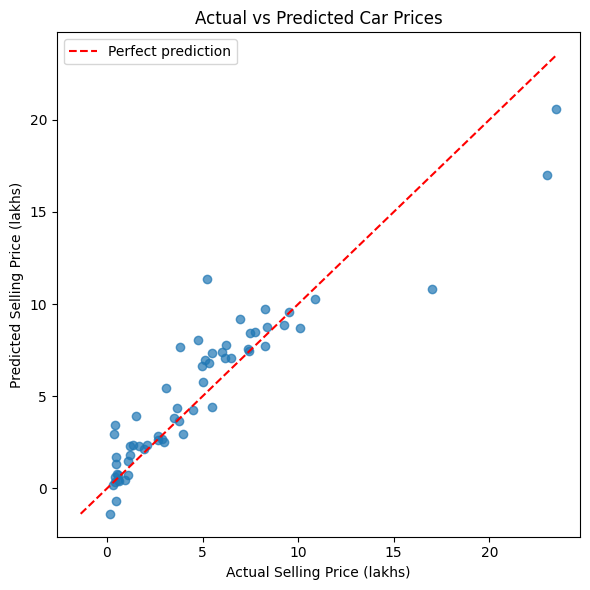

In [10]:
# 10. Plot Actual vs Predicted prices

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Selling Price (lakhs)")
plt.ylabel("Predicted Selling Price (lakhs)")
plt.title("Actual vs Predicted Car Prices")

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], "r--", label="Perfect prediction")

plt.legend()
plt.tight_layout()
plt.show()

# 11. Simple explanation: Real-world use of this model

In real life, this kind of car price prediction model can be used for:

- Car resale websites: to suggest a fair selling price when a user wants to sell a car.
- Car dealers: to quickly estimate how much they should pay for a used car.
- Banks / loan companies: to check the value of a car before giving a loan.

Here we built a **small, internship-level version** of that idea using:
- **pandas** for working with the car dataset
- **scikit-learn** for training a simple regression model
- **matplotlib** for drawing graphs

We used features like:
- Car age (newer cars usually cost more)
- Brand popularity (how common that car name is in our data)
- Fuel type, transmission, driven kilometers, and more

In a bigger real-world project, we would also include extra features like:
- Horsepower
- Mileage (km per litre)
- Engine size

But the main idea is the same: **use past data to learn a pattern, and then predict a fair price for new cars.**